# Freight Rate Prediction — Exploration, Validation & Charts



In [6]:

!pip install -q lightgbm xgboost


In [7]:
from google.colab import files
import io

print("Upload: train_test.csv, validation.csv, december_chart_inputs.csv "
      "(and validation_predictions_template.csv if you have it)")


Upload: train_test.csv, validation.csv, december_chart_inputs.csv (and validation_predictions_template.csv if you have it)


In [8]:
import pandas as pd
import numpy as np

# Directly assign the file paths based on the kernel state
train_file_path = '/content/train-test.csv'
val_file_path = '/content/validation.csv'
dec_file_path = '/content/december_chart_inputs.csv'
template_file_path = '/content/validation-predictions-template.csv'

# Load the dataframes
train_df = pd.read_csv(train_file_path, parse_dates=['date'])
val_df = pd.read_csv(val_file_path, parse_dates=['date'])
dec_df = pd.read_csv(dec_file_path)
template_df = pd.read_csv(template_file_path)

print(train_df.shape, val_df.shape, dec_df.shape)
train_df.head()

(48000, 14) (12000, 13) (31, 7)


,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


## 1. Data Exploration

Charts and summaries useful for the "key findings" section of your Loom video.


In [9]:
import matplotlib.pyplot as plt

print("Missing values (train):")
print(train_df.isna().sum()[train_df.isna().sum() > 0])
print("\nMissing values (validation):")
print(val_df.isna().sum()[val_df.isna().sum() > 0])


Missing values (train):
weight          300
market_index    374
dtype: int64

Missing values (validation):
weight          165
market_index    249
dtype: int64


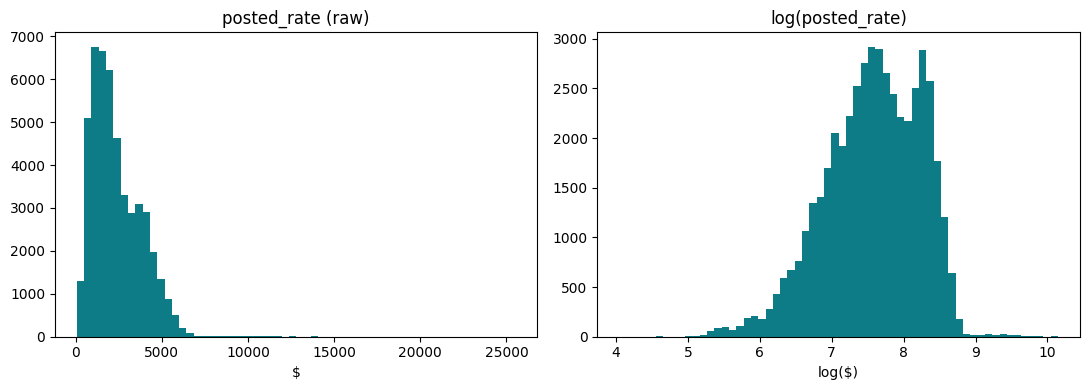

In [10]:

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(train_df['posted_rate'], bins=60, color='#0E7C86')
axes[0].set_title('posted_rate (raw)')
axes[0].set_xlabel('$')

axes[1].hist(np.log(train_df['posted_rate']), bins=60, color='#0E7C86')
axes[1].set_title('log(posted_rate)')
axes[1].set_xlabel('log($)')
plt.tight_layout()
plt.show()


Rows with negative weight: 292 (0.61%)


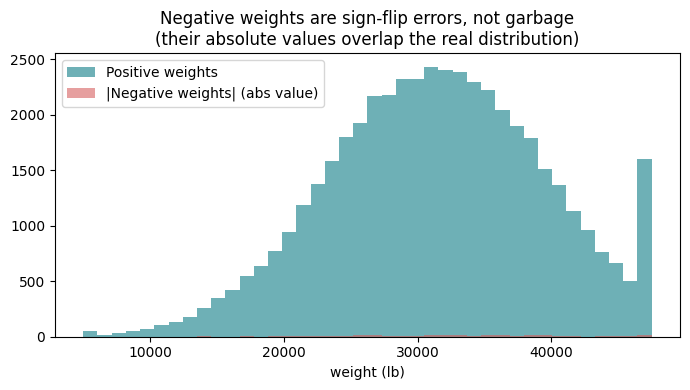

In [11]:

neg = (train_df['weight'] < 0).sum()
print(f"Rows with negative weight: {neg} ({neg/len(train_df)*100:.2f}%)")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(train_df.loc[train_df['weight'] >= 0, 'weight'].dropna(), bins=40,
        alpha=0.6, label='Positive weights', color='#0E7C86')
ax.hist(train_df.loc[train_df['weight'] < 0, 'weight'].abs().dropna(), bins=40,
        alpha=0.6, label='|Negative weights| (abs value)', color='#D65F5F')
ax.set_title('Negative weights are sign-flip errors, not garbage\n(their absolute values overlap the real distribution)')
ax.set_xlabel('weight (lb)')
ax.legend()
plt.tight_layout()
plt.show()


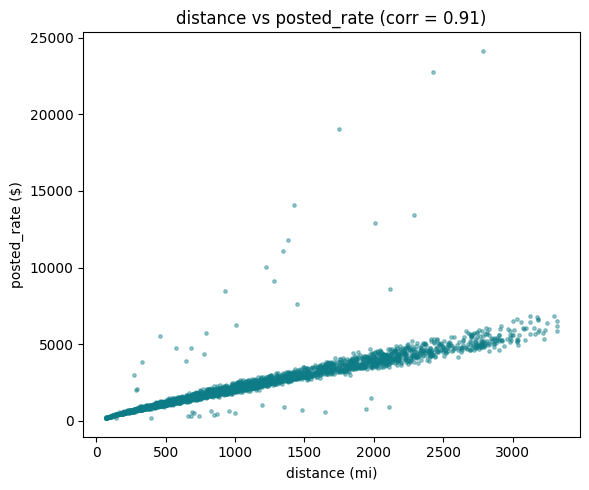

In [12]:

fig, ax = plt.subplots(figsize=(6, 5))
sample = train_df.sample(3000, random_state=0)
ax.scatter(sample['distance'], sample['posted_rate'], s=6, alpha=0.4, color='#0E7C86')
ax.set_xlabel('distance (mi)')
ax.set_ylabel('posted_rate ($)')
ax.set_title(f"distance vs posted_rate (corr = {train_df['distance'].corr(train_df['posted_rate']):.2f})")
plt.tight_layout()
plt.show()


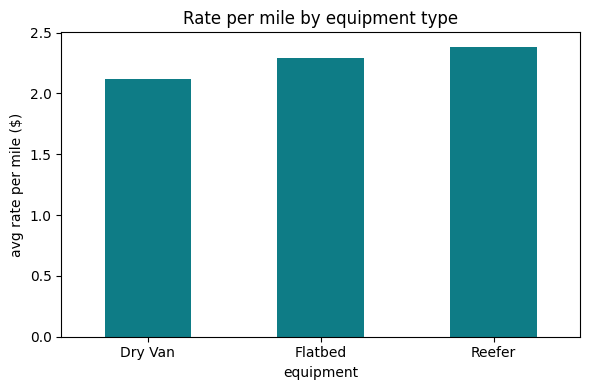

In [13]:

rpm = train_df.copy()
rpm['rate_per_mile'] = rpm['posted_rate'] / rpm['distance']
by_equip = rpm.groupby('equipment')['rate_per_mile'].mean().sort_values()

fig, ax = plt.subplots(figsize=(6, 4))
by_equip.plot(kind='bar', ax=ax, color='#0E7C86')
ax.set_ylabel('avg rate per mile ($)')
ax.set_title('Rate per mile by equipment type')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


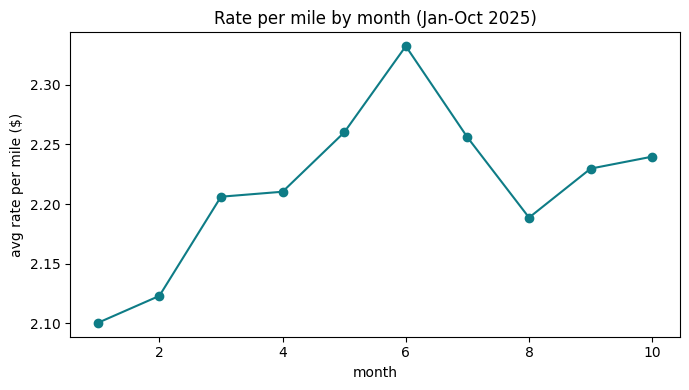

In [14]:

rpm['month'] = rpm['date'].dt.month
by_month = rpm.groupby('month')['rate_per_mile'].mean()

fig, ax = plt.subplots(figsize=(7, 4))
by_month.plot(marker='o', ax=ax, color='#0E7C86')
ax.set_xlabel('month')
ax.set_ylabel('avg rate per mile ($)')
ax.set_title('Rate per mile by month (Jan-Oct 2025)')
plt.tight_layout()
plt.show()


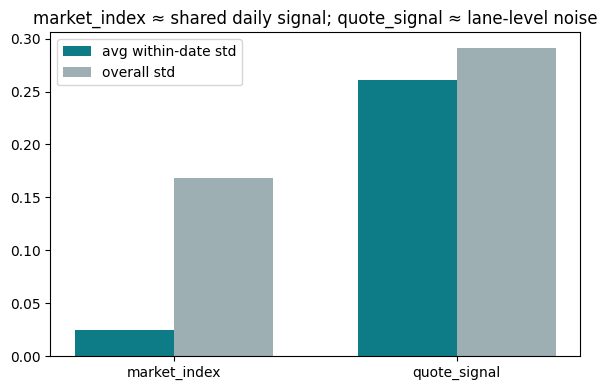

In [15]:

by_date_mi = train_df.groupby('date')['market_index'].std()
by_date_qs = train_df.groupby('date')['quote_signal'].std()

fig, ax = plt.subplots(figsize=(6, 4))
labels = ['market_index', 'quote_signal']
within_date_std = [by_date_mi.mean(), by_date_qs.mean()]
overall_std = [train_df['market_index'].std(), train_df['quote_signal'].std()]
x = np.arange(2)
width = 0.35
ax.bar(x - width/2, within_date_std, width, label='avg within-date std', color='#0E7C86')
ax.bar(x + width/2, overall_std, width, label='overall std', color='#9DAFB3')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_title('market_index ≈ shared daily signal; quote_signal ≈ lane-level noise')
ax.legend()
plt.tight_layout()
plt.show()


## 2. Feature Engineering

Same feature set as `train_model.py`: spatial (haversine, circuity), temporal
(cyclical day/month encodings), interactions (distance × weight/market/quote),
and equipment encoding.


In [16]:
LEXINGTON_COORDS = (36.99152, -84.99876)
FORT_WAYNE_COORDS = (41.31561, -85.36206)
EQUIPMENT_MAP = {"Dry Van": 0, "Reefer": 1, "Flatbed": 2}

def haversine_np(lat1, lon1, lat2, lon2):
    R = 3958.8
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlam = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2.0) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlam / 2.0) ** 2
    return 2.0 * R * np.arcsin(np.sqrt(np.clip(a, 0.0, 1.0)))

def engineer_features(df, city_lat_map=None, city_lon_map=None, dec_daily_signals=None,
                       is_dec=False, median_weight=30000.0, median_market_index=1.05):
    data = df.copy()
    data['date'] = pd.to_datetime(data['date'])

    if is_dec:
        data['pickup_lat'] = LEXINGTON_COORDS[0]
        data['pickup_lon'] = LEXINGTON_COORDS[1]
        data['delivery_lat'] = FORT_WAYNE_COORDS[0]
        data['delivery_lon'] = FORT_WAYNE_COORDS[1]
        if dec_daily_signals is not None:
            data = data.merge(dec_daily_signals, on='date', how='left')

    if city_lat_map and city_lon_map:
        if 'pickup_lat' in data.columns:
            data['pickup_lat'] = data['pickup_lat'].fillna(data['pickup'].map(city_lat_map))
            data['pickup_lon'] = data['pickup_lon'].fillna(data['pickup'].map(city_lon_map))
            data['delivery_lat'] = data['delivery_lat'].fillna(data['delivery'].map(city_lat_map))
            data['delivery_lon'] = data['delivery_lon'].fillna(data['delivery'].map(city_lon_map))


    data['weight'] = data['weight'].abs()
    data['weight'] = data['weight'].fillna(median_weight)
    if 'market_index' in data.columns:
        data['market_index'] = data['market_index'].fillna(median_market_index)
    else:
        data['market_index'] = median_market_index
    if 'quote_signal' not in data.columns:
        data['quote_signal'] = 2.05

    data['equipment_code'] = data['equipment'].map(EQUIPMENT_MAP).fillna(0).astype(int)

    lat1, lon1 = data['pickup_lat'].values, data['pickup_lon'].values
    lat2, lon2 = data['delivery_lat'].values, data['delivery_lon'].values
    data['haversine_dist'] = haversine_np(lat1, lon1, lat2, lon2)
    data['lat_diff'] = lat2 - lat1
    data['lon_diff'] = lon2 - lon1
    data['mid_lat'] = (lat1 + lat2) / 2.0
    data['mid_lon'] = (lon1 + lon2) / 2.0
    data['circuity'] = data['distance'] / (data['haversine_dist'] + 1.0)

    dt = data['date'].dt
    data['day_of_week'] = dt.dayofweek
    data['day_of_month'] = dt.day
    data['month'] = dt.month
    data['week_of_year'] = dt.isocalendar().week.astype(int)
    data['is_weekend'] = (data['day_of_week'] >= 5).astype(int)
    data['sin_dow'] = np.sin(2 * np.pi * data['day_of_week'] / 7.0)
    data['cos_dow'] = np.cos(2 * np.pi * data['day_of_week'] / 7.0)
    data['sin_month'] = np.sin(2 * np.pi * (data['month'] - 1) / 12.0)
    data['cos_month'] = np.cos(2 * np.pi * (data['month'] - 1) / 12.0)

    data['dist_x_qs'] = data['distance'] * data['quote_signal']
    data['dist_x_mkt'] = data['distance'] * data['market_index']
    data['dist_x_weight'] = data['distance'] * (data['weight'] / 10000.0)
    data['weight_per_mile'] = data['weight'] / (data['distance'] + 1.0)
    return data

FEATURE_COLS = [
    "distance", "haversine_dist", "circuity", "lat_diff", "lon_diff",
    "pickup_lat", "pickup_lon", "delivery_lat", "delivery_lon", "mid_lat", "mid_lon",
    "weight", "equipment_code", "market_index", "quote_signal",
    "dist_x_qs", "dist_x_mkt", "dist_x_weight", "weight_per_mile",
    "day_of_week", "day_of_month", "month", "week_of_year", "is_weekend",
    "sin_dow", "cos_dow", "sin_month", "cos_month",
]
print(f"{len(FEATURE_COLS)} features defined")


28 features defined


In [17]:

city_lat = pd.concat([train_df.groupby('pickup')['pickup_lat'].median(),
                       train_df.groupby('delivery')['delivery_lat'].median()]).to_dict()
city_lon = pd.concat([train_df.groupby('pickup')['pickup_lon'].median(),
                       train_df.groupby('delivery')['delivery_lon'].median()]).to_dict()
med_weight = float(train_df['weight'].abs().median())
med_mkt = float(train_df['market_index'].median())

dec_daily_signals = (
    val_df[val_df['date'].dt.month == 12]
    .groupby('date')[['market_index', 'quote_signal']].mean().reset_index()
)

train_feat = engineer_features(train_df, city_lat, city_lon, median_weight=med_weight, median_market_index=med_mkt)
val_feat = engineer_features(val_df, city_lat, city_lon, median_weight=med_weight, median_market_index=med_mkt)
dec_feat = engineer_features(dec_df, city_lat, city_lon, dec_daily_signals=dec_daily_signals,
                              is_dec=True, median_weight=med_weight, median_market_index=med_mkt)

X_full = train_feat[FEATURE_COLS]
y_full = train_feat['posted_rate'].values
log_y_full = np.log(y_full)
print("Feature matrix:", X_full.shape)


Feature matrix: (48000, 28)


## 3. Validation Strategy

Temporal hold-out (train Jan-Sep, test Oct) since the real prediction task
requires extrapolating into unseen Nov/Dec — plus 5-fold cross-validation
for a general accuracy estimate.


In [18]:
import lightgbm as lgb
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold

RANDOM_STATE = 42

def evaluate_metrics(y_true, y_pred):
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    r2 = float(r2_score(y_true, y_pred))
    mape = float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100.0)
    return {"RMSE": rmse, "MAE": mae, "R2": r2, "MAPE": mape}

def make_lgb():
    return lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.03, num_leaves=63,
                              subsample=0.85, colsample_bytree=0.85,
                              random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)

def make_xgb():
    return xgb.XGBRegressor(n_estimators=1000, learning_rate=0.03, max_depth=6,
                             subsample=0.85, colsample_bytree=0.85,
                             random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)


In [19]:

split_date = pd.Timestamp('2025-10-01')
tr_mask = train_feat['date'] < split_date
oos_mask = train_feat['date'] >= split_date

X_tr, log_y_tr = train_feat.loc[tr_mask, FEATURE_COLS], log_y_full[tr_mask]
X_oos, y_oos = train_feat.loc[oos_mask, FEATURE_COLS], y_full[oos_mask]
print(f"Train (Jan-Sep): {len(X_tr):,} | Hold-out (Oct): {len(X_oos):,}")

m_lgb, m_xgb = make_lgb(), make_xgb()
m_lgb.fit(X_tr, log_y_tr)
m_xgb.fit(X_tr, log_y_tr)

pred_oos = 0.5 * np.exp(m_lgb.predict(X_oos)) + 0.5 * np.exp(m_xgb.predict(X_oos))
holdout_metrics = evaluate_metrics(y_oos, pred_oos)
print("Hold-out metrics:", {k: round(v, 3) for k, v in holdout_metrics.items()})


Train (Jan-Sep): 43,147 | Hold-out (Oct): 4,853
Hold-out metrics: {'RMSE': 660.008, 'MAE': 169.504, 'R2': 0.814, 'MAPE': 8.141}


In [20]:

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []
for fold, (tr_idx, va_idx) in enumerate(kf.split(X_full), 1):
    fl, fx = make_lgb(), make_xgb()
    fl.fit(X_full.iloc[tr_idx], log_y_full[tr_idx])
    fx.fit(X_full.iloc[tr_idx], log_y_full[tr_idx])
    fold_pred = 0.5 * np.exp(fl.predict(X_full.iloc[va_idx])) + 0.5 * np.exp(fx.predict(X_full.iloc[va_idx]))
    m = evaluate_metrics(y_full[va_idx], fold_pred)
    m['fold'] = fold
    cv_rows.append(m)
    print(f"Fold {fold}: RMSE=${m['RMSE']:.2f} MAE=${m['MAE']:.2f} R2={m['R2']:.4f} MAPE={m['MAPE']:.2f}%")

cv_df = pd.DataFrame(cv_rows)
print("\nMean CV:", cv_df[['RMSE','MAE','R2','MAPE']].mean().round(3).to_dict())


Fold 1: RMSE=$532.16 MAE=$104.22 R2=0.8676 MAPE=4.83%
Fold 2: RMSE=$614.08 MAE=$109.96 R2=0.8283 MAPE=4.83%
Fold 3: RMSE=$616.87 MAE=$112.33 R2=0.8296 MAPE=5.26%
Fold 4: RMSE=$616.03 MAE=$110.86 R2=0.8342 MAPE=4.94%
Fold 5: RMSE=$594.07 MAE=$107.73 R2=0.8389 MAPE=4.87%

Mean CV: {'RMSE': 594.643, 'MAE': 109.019, 'R2': 0.84, 'MAPE': 4.947}


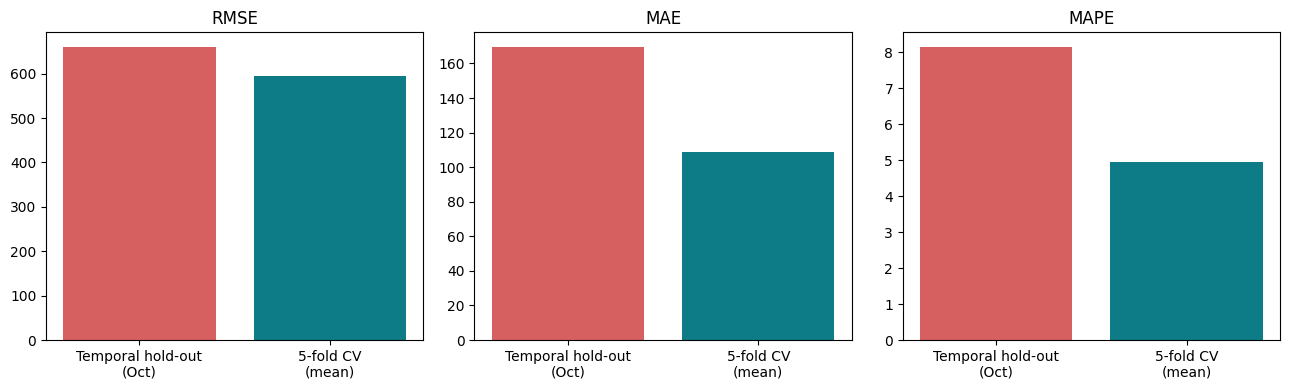

In [21]:

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
metrics_names = ['RMSE', 'MAE', 'MAPE']
for ax, name in zip(axes, metrics_names):
    vals = [holdout_metrics[name], cv_df[name].mean()]
    ax.bar(['Temporal hold-out\n(Oct)', '5-fold CV\n(mean)'], vals, color=['#D65F5F', '#0E7C86'])
    ax.set_title(name)
plt.tight_layout()
plt.show()


## 4. Final Model, Predictions & Feature Importance


In [22]:

final_lgb, final_xgb = make_lgb(), make_xgb()
final_lgb.fit(X_full, log_y_full)
final_xgb.fit(X_full, log_y_full)
print("Final ensemble trained on", len(X_full), "rows")


Final ensemble trained on 48000 rows


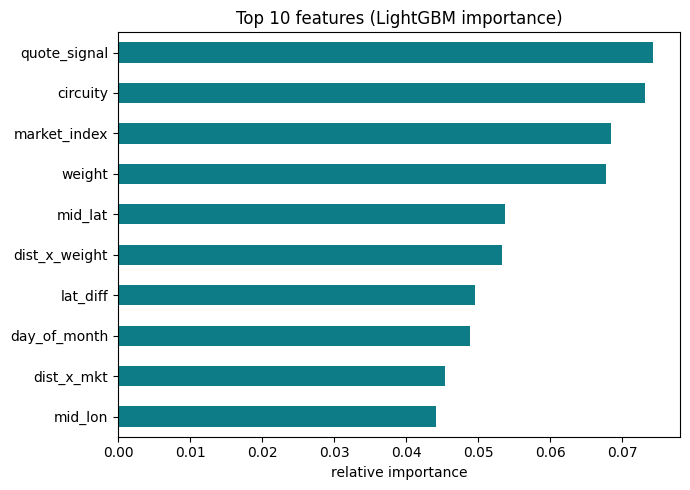

In [23]:

fi = pd.Series(final_lgb.feature_importances_, index=FEATURE_COLS)
fi = (fi / fi.sum()).sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(7, 5))
fi[::-1].plot(kind='barh', ax=ax, color='#0E7C86')
ax.set_title('Top 10 features (LightGBM importance)')
ax.set_xlabel('relative importance')
plt.tight_layout()
plt.show()


In [24]:

X_val = val_feat[FEATURE_COLS]
val_pred = 0.5 * np.exp(final_lgb.predict(X_val)) + 0.5 * np.exp(final_xgb.predict(X_val))
val_pred = np.clip(val_pred, 10.0, None)

preds_by_id = pd.Series(np.round(val_pred, 2), index=val_feat['load_id'].values)
if template_df is not None:
    submission_df = template_df[['load_id']].copy()
    submission_df['predicted_rate'] = submission_df['load_id'].map(preds_by_id)
else:
    submission_df = pd.DataFrame({'load_id': val_feat['load_id'], 'predicted_rate': np.round(val_pred, 2)})

submission_df.to_csv('validation_predictions.csv', index=False)
print(submission_df.head())
print(f"\nWrote {len(submission_df):,} rows -> validation_predictions.csv")


     load_id  predicted_rate
0  TE-000001          812.66
1  TE-000002         5067.06
2  TE-000003         5272.03
3  TE-000004         4002.63
4  TE-000005         1829.51

Wrote 12,000 rows -> validation_predictions.csv


In [25]:

X_dec = dec_feat[FEATURE_COLS]
dec_pred = 0.5 * np.exp(final_lgb.predict(X_dec)) + 0.5 * np.exp(final_xgb.predict(X_dec))
dec_pred = np.clip(dec_pred, 10.0, None)

dec_out = dec_df.copy()
dec_out['predicted_rate'] = np.round(dec_pred, 2)
dec_out.to_csv('december_chart_inputs.csv', index=False)
print(dec_out)


       pickup    delivery  distance equipment  weight        date  \
0   Lexington  Fort Wayne       360   Dry Van   32000  2025-12-01   
1   Lexington  Fort Wayne       360   Dry Van   32000  2025-12-02   
2   Lexington  Fort Wayne       360   Dry Van   32000  2025-12-03   
3   Lexington  Fort Wayne       360   Dry Van   32000  2025-12-04   
4   Lexington  Fort Wayne       360   Dry Van   32000  2025-12-05   
5   Lexington  Fort Wayne       360   Dry Van   32000  2025-12-06   
6   Lexington  Fort Wayne       360   Dry Van   32000  2025-12-07   
7   Lexington  Fort Wayne       360   Dry Van   32000  2025-12-08   
8   Lexington  Fort Wayne       360   Dry Van   32000  2025-12-09   
9   Lexington  Fort Wayne       360   Dry Van   32000  2025-12-10   
10  Lexington  Fort Wayne       360   Dry Van   32000  2025-12-11   
11  Lexington  Fort Wayne       360   Dry Van   32000  2025-12-12   
12  Lexington  Fort Wayne       360   Dry Van   32000  2025-12-13   
13  Lexington  Fort Wayne       36

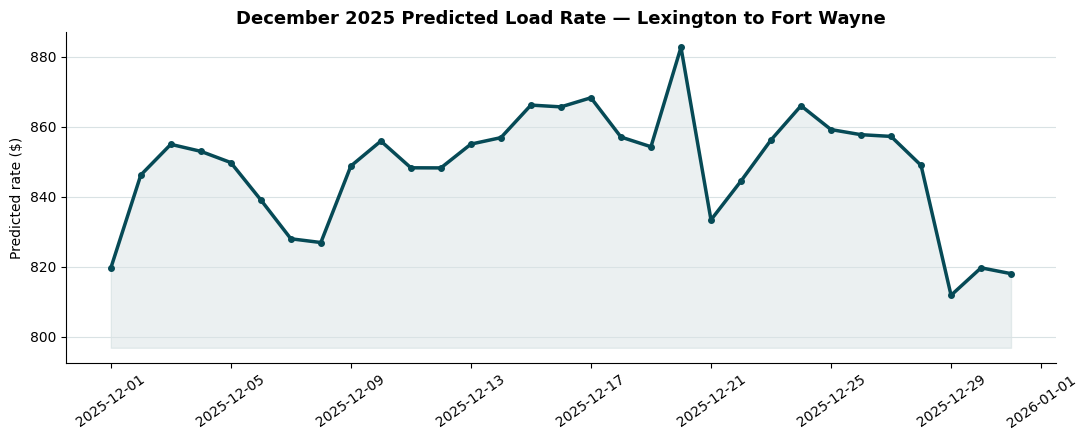

In [26]:

fig, ax = plt.subplots(figsize=(11, 4.5))
dec_out['date'] = pd.to_datetime(dec_out['date'])
dec_sorted = dec_out.sort_values('date')
ax.plot(dec_sorted['date'], dec_sorted['predicted_rate'], color='#064A56', linewidth=2.5, marker='o', markersize=4)
ax.fill_between(dec_sorted['date'], dec_sorted['predicted_rate'], dec_sorted['predicted_rate'].min() - 15,
                color='#064A56', alpha=0.08)
ax.set_title('December 2025 Predicted Load Rate — Lexington to Fort Wayne', fontsize=13, fontweight='bold')
ax.set_ylabel('Predicted rate ($)')
ax.grid(axis='y', color='#D9E2E4')
ax.spines[['top', 'right']].set_visible(False)
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()


In [27]:

from google.colab import files
files.download('validation_predictions.csv')
files.download('december_chart_inputs.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>